In [1]:
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from jordanutils import *
from sklearn.model_selection import train_test_split


rng = np.random.default_rng(seed=123)

Generowanie danych treningowych: 
- J - blok Jordana, gdzie `lam` oznacza wartości na przekątnej, a `block_size` oznacza liczbę "1" nad przekątną, np. dla `lam = 0`, `block_size = 3`: $J = \begin{bmatrix}
0 & 1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 \\
\end{bmatrix}$. Używanie innych wartości własnych niż 0 nie wpływa na rezultaty. 
- S - losowa macierz przejścia
- do treningu idzie macierz $ X = SJS^{-1}$
- używałem macierzy $ 5 \times 5$. 
- dane składały się ze 100 000 macierzy, po 20 000 z każdej kategorii. 20% danych jest danymi testowymi. 20% z danych treningowych wydzielono na "valid set" do oceny postępu uczenia sieci neuronowej.

In [6]:
d = 5 
dataset_size = 50000
X, y = generate_testset(d, dataset_size, mode="int")
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    # stratify=y, 
    random_state=123
)
print(y_train[-1])
X_test, y_test = generate_testset(d, int(dataset_size * 0.2), mode="random")

X_train = X_train.astype(np.float32)
y_train = np.array(y_train, dtype=np.int32)
y_val   = np.array(y_val, dtype=np.int32)

model1 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(d, d)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(d)
])

model1.compile(optimizer='adam',
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=3,            
    restore_best_weights=True
)

model1.fit(
    X_train, y_train,
    epochs=50, 
    validation_data=(X_val, y_val),   
    callbacks=[early_stop],
)



y_predicted = model1.predict(X_test)
y_predicted = np.argmax(y_predicted, axis=1)

4
Epoch 1/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.5068 - loss: 1.0667 - val_accuracy: 0.5909 - val_loss: 0.8568
Epoch 2/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.5945 - loss: 0.8519 - val_accuracy: 0.6180 - val_loss: 0.7918
Epoch 3/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.6199 - loss: 0.7915 - val_accuracy: 0.6279 - val_loss: 0.7702
Epoch 4/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.6241 - loss: 0.8014 - val_accuracy: 0.6379 - val_loss: 0.7557
Epoch 5/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.6395 - loss: 0.7461 - val_accuracy: 0.6534 - val_loss: 0.7184
Epoch 6/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.6462 - loss: 0.7480 - val_accuracy: 0.6504 - val_loss: 0.7239
Epoch 7/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.6598 - loss: 0.7057 - val_accuracy: 0.6574 - val_loss: 0.7103
Epoch 8/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.6545 - loss:

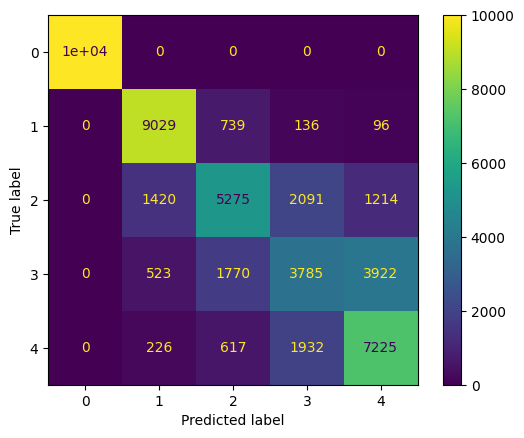

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10000
           1       0.81      0.90      0.85     10000
           2       0.63      0.53      0.57     10000
           3       0.48      0.38      0.42     10000
           4       0.58      0.72      0.64     10000

    accuracy                           0.71     50000
   macro avg       0.70      0.71      0.70     50000
weighted avg       0.70      0.71      0.70     50000



In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_predicted)
ConfusionMatrixDisplay(cm).plot()
plt.show()

print(classification_report(y_test, y_predicted))

In [9]:
d = 5
dataset_size = 50000
X, y = generate_testset(d, dataset_size, mode="upper")
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y, 
    random_state=123
)
print(y_train[-1])
X_test, y_test = generate_testset(d, int(dataset_size * 0.2), mode="random")

X_train = X_train.astype(np.float32)
y_train = np.array(y_train, dtype=np.int32)
y_val   = np.array(y_val, dtype=np.int32)

model1 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(d, d)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(d)
])

model1.compile(optimizer='adam',
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=3,            
    restore_best_weights=True
)

model1.fit(
    X_train, y_train,
    epochs=50, 
    validation_data=(X_val, y_val),   
    callbacks=[early_stop],
)



y_predicted = model1.predict(X_test)
y_predicted = np.argmax(y_predicted, axis=1)

3
Epoch 1/50


c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6250/6250 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.8323 - loss: 0.4733 - val_accuracy: 0.9339 - val_loss: 0.1557
Epoch 2/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9490 - loss: 0.1262 - val_accuracy: 0.9646 - val_loss: 0.0747
Epoch 3/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9564 - loss: 0.1102 - val_accuracy: 0.9660 - val_loss: 0.0828
Epoch 4/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9651 - loss: 0.0888 - val_accuracy: 0.9725 - val_loss: 0.0634
Epoch 5/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9637 - loss: 0.0982 - val_accuracy: 0.9696 - val_loss: 0.0741
Epoch 6/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9648 - loss: 0.0917 - val_accuracy: 0.9678 - val_loss: 0.0766
Epoch 7/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9688 - loss: 0.0793 - val_accuracy: 0.9643 - val_loss: 0.0778
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 721us/step


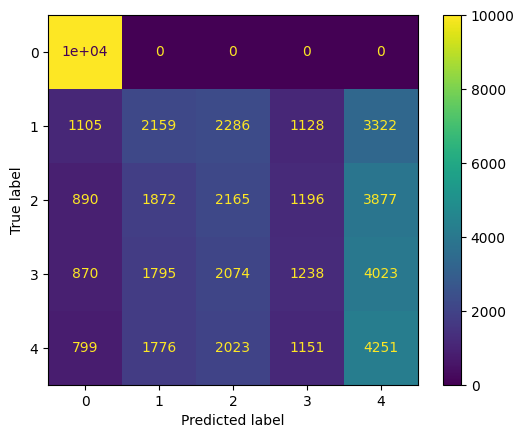

              precision    recall  f1-score   support

           0       0.73      1.00      0.85     10000
           1       0.28      0.22      0.25     10000
           2       0.25      0.22      0.23     10000
           3       0.26      0.12      0.17     10000
           4       0.27      0.43      0.33     10000

    accuracy                           0.40     50000
   macro avg       0.36      0.40      0.37     50000
weighted avg       0.36      0.40      0.37     50000



In [10]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_predicted)
ConfusionMatrixDisplay(cm).plot()
plt.show()

print(classification_report(y_test, y_predicted))